# TP

The goal of this exercise is to build a classifier for a public [dataset](https://archive.ics.uci.edu/ml/datasets/car+evaluation) (Click for info and details).

### Instructions
   * Download the dataset from [here]() (csv file) and place it in the same folder of this notebook
   * Read carefully the text
   * Complete the code cells when asked
   * For each section, use as many cells as you want.
   * If possible, try to insert comments (`# this is a comment`) in your code cells explaining your ideas or create some text cells (`markdown`)
   * Run every cell!
   * Save the notebook 
   * Rename the notebook with your surname and send it via email to marco.milanesio@univ-cotedazur.fr
   * **DEADLINE: TODAY AT 12h30** Emails arrived past this time will not be considered.

### Useful links
   * [Sklearn classifiers](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) 
   * [Pandas dataframe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html)

## Section 0: WARM UP

Run the following cells.

The first will install an optional library that will be used later in the notebook. If you can't install it via the `magic function` (`!` operator), then you have to close the notebook and install it from you environment (as you did for `sklearn`)

In [1]:
!python3 -m pip install category_encoders

This will import everything you'll need in this notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.model_selection import train_test_split
import category_encoders as ce  # provided that the cell before worked properly or that you have it installed in other way
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix


## SECTION 1: LOADING

   * Load the data into a `pandas` dataframe
   * Inspect some of the features of the loaded data (shape, types, unique values, etc...)

In [4]:
# This will show the first line of the file
!head car_evaluation.csv

Must specify that no header is given when loading. 

As for the column names, use the following: 
```
names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
```

In [5]:
data = pd.read_csv('car_evaluation.csv', header=None, names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'])

In [6]:
data.shape

(1728, 7)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
for col in data.columns:
    print(data[col].value_counts()) 
    print()

low      432
high     432
vhigh    432
med      432
Name: buying, dtype: int64

low      432
high     432
vhigh    432
med      432
Name: maint, dtype: int64

3        432
5more    432
2        432
4        432
Name: doors, dtype: int64

2       576
4       576
more    576
Name: persons, dtype: int64

small    576
med      576
big      576
Name: lug_boot, dtype: int64

low     576
high    576
med     576
Name: safety, dtype: int64

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64



## SECTION 2: MODELLING (part I)

The `class` attribute is the target variable that we want to model/forecast.
  * Count the different number of values in the `class` attribute
  * Create a new dataframe `X` with the `class` column dropped
  * Create a Series `y` with values from the attribute `class`
  * Split the `X` and `y` into `training` and `testing` set.
  * What are the sizes of `X` and `y`?

#### OPTIONAL
you can influence the ratio of the sizes of `training` and `testing` by using the name parameter `test_size` in the `train_test_split` method. More info [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  

In [9]:
data['class'].value_counts()

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64

In [10]:
X = data.drop(['class'], axis=1)
y = data['class']


In [11]:
type(y)

pandas.core.series.Series

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)


In [14]:
X_train.shape, X_test.shape


((1157, 6), (571, 6))

In [15]:
X_train.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
dtype: object

## SECTION 2bis: ENCODING

When dealing with categorical variables, like in this case, you need to **encode** them in a numerical format. 
Run the following cell to see it in action.

In [19]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])


X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1261,1,1,1,1,1,1
1727,2,1,2,1,2,2
548,3,2,3,2,2,2
1507,2,2,2,1,3,1
494,3,3,1,2,2,2


Now we can use the categorical variables as numerical!! `OrdinalEncoder` translate the variables into `integers`. Many other encoders exist. We will see a couple of them in the next lectures.

## SECTION 3: MODELLING (part II)

For this particular task we will use a `DecisionTreeClassifier`.
  * Fit the training data
  * Calculate the accuracy scores on the `training` and `testing` set
  * Predict the `y_test` values and calculate the corresponding accuracy score
 
### HINT
  * Use the default criterion: `clf = DecisionTreeClassifier(max_depth=3, random_state=0)`


In [20]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1261,1,1,1,1,1,1
1727,2,1,2,1,2,2
548,3,2,3,2,2,2
1507,2,2,2,1,3,1
494,3,3,1,2,2,2


In [21]:
clf = DecisionTreeClassifier(max_depth=3, random_state=0)

clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=0)

In [22]:
y_pred = clf.predict(X_test)

In [23]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.7846


In [24]:
y_pred_train = clf.predict(X_train)
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))


Training-set accuracy score: 0.7848


In [25]:
print('Training set score: {:.4f}'.format(clf.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(clf.score(X_test, y_test)))


Training set score: 0.7848
Test set score: 0.7846


## SECTION 3bis: VISUALIZATION

You can visualize the result of the classifier by plotting the tree.
Run the followin cell

[Text(418.5, 380.52, 'X[5] <= 2.5\ngini = 0.456\nsamples = 1157\nvalue = [258, 42, 811, 46]'),
 Text(334.8, 271.8, 'X[3] <= 2.5\ngini = 0.58\nsamples = 765\nvalue = [258, 42, 419, 46]'),
 Text(167.4, 163.07999999999998, 'X[3] <= 1.5\ngini = 0.495\nsamples = 509\nvalue = [124, 22, 338, 25]'),
 Text(83.7, 54.360000000000014, 'gini = 0.638\nsamples = 255\nvalue = [124, 22, 84, 25]'),
 Text(251.10000000000002, 54.360000000000014, 'gini = 0.0\nsamples = 254\nvalue = [0, 0, 254, 0]'),
 Text(502.20000000000005, 163.07999999999998, 'X[0] <= 2.5\ngini = 0.613\nsamples = 256\nvalue = [134, 20, 81, 21]'),
 Text(418.5, 54.360000000000014, 'gini = 0.614\nsamples = 122\nvalue = [69, 20, 12, 21]'),
 Text(585.9, 54.360000000000014, 'gini = 0.5\nsamples = 134\nvalue = [65, 0, 69, 0]'),
 Text(502.20000000000005, 271.8, 'gini = 0.0\nsamples = 392\nvalue = [0, 0, 392, 0]')]

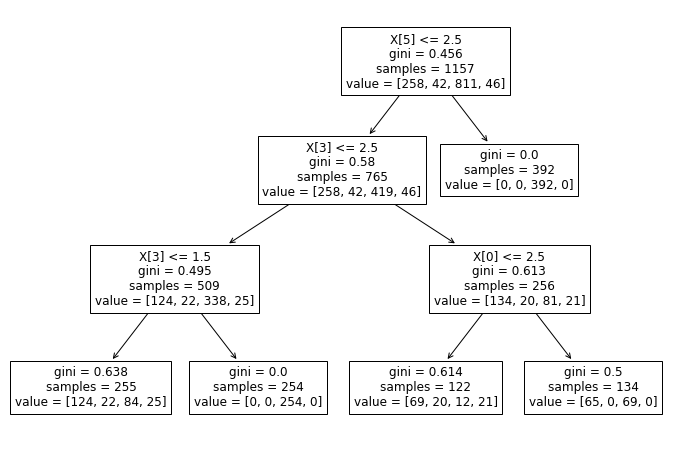

In [26]:
plt.figure(figsize=(12,8))


tree.plot_tree(clf.fit(X_train, y_train)) 

## SECTION 4: EVALUATION

  * Print the confusion matrix of the model
  * Print the classification report of the model


In [27]:

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)



Confusion matrix

 [[101   0  25   0]
 [ 27   0   0   0]
 [ 52   0 347   0]
 [ 19   0   0   0]]


In [28]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         acc       0.51      0.80      0.62       126
        good       0.00      0.00      0.00        27
       unacc       0.93      0.87      0.90       399
       vgood       0.00      0.00      0.00        19

    accuracy                           0.78       571
   macro avg       0.36      0.42      0.38       571
weighted avg       0.76      0.78      0.77       571



/home/marco/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## SECTION 5: OPTIONAL

  * Redo the analysis using the `entropy` criterion: `DecisionTreeClassifier(criterion='entropy', ...)`
  * How do the results change?
  * Can you tell what is best?